# Tutorial for using SWASH data in Parcels

In [1]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import uxarray as ux
import xarray as xr

import parcels
import parcels.tutorial
import glob


/var/folders/2v/5l455kn13xq41s2x_zl1chlr0000gn/T/ipykernel_87891/208841806.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
grid_file = parcels.tutorial.open_dataset(
    "SWASH_data/data", download_only=True
)
print(grid_file)


['/Users/YanTo001/Library/Caches/parcels/data-matlab/F1ALL.mat', '/Users/YanTo001/Library/Caches/parcels/data-matlab/F1GRD.mat']


In [3]:
# grid_file = "/Users/YanTo001/Documents/GitHub/parcels-data/data-matlab/F1GRD.mat"#"/Users/YanTo001/Library/Caches/parcels/data-matlab/F1GRD.mat"
# result_file = "/Users/YanTo001/Documents/GitHub/parcels-data/data-matlab/F1ALL.mat"#"/Users/YanTo001/Library/Caches/parcels/data-matlab/F1ALL.mat"
# ds = parcels.convert.swash_to_sgrid(grid_file, result_file, total_depth=8.0)
ds = parcels.convert.swash_to_sgrid(grid_file[1], grid_file[0], total_depth=8.0)

fieldset = parcels.FieldSet.from_sgrid_conventions(ds)


In [5]:
npart = 150  # number of particles to be released
# release particles in a line along a meridian
lat = np.linspace(1, 16, npart) ## y
lon = np.repeat(15, npart) ## x
time = np.repeat(ds.time.values[0], npart)
layerI = 0 # at which water depth, the particles are released
z = np.repeat(ds.depth.values[layerI], npart)
pset = parcels.ParticleSet(fieldset=fieldset, pclass=parcels.Particle, t=time, x=lon, y=lat, z=z)
kernels = [parcels.kernels.AdvectionRK2]

output_file = parcels.ParticleFile("output-quickstart.parquet", outputdt=np.timedelta64(5, "s"), mode="w") # 
pset.execute(
    kernels,
    runtime=np.timedelta64(20, "s"),
    dt=np.timedelta64(5, "s"),
    output_file=output_file,
)

INFO: Output files are stored in output-quickstart.parquet
Integration time: 2026-06-01T00:00:15 100%|██████████| [00:00<00:00, 909.13it/s]


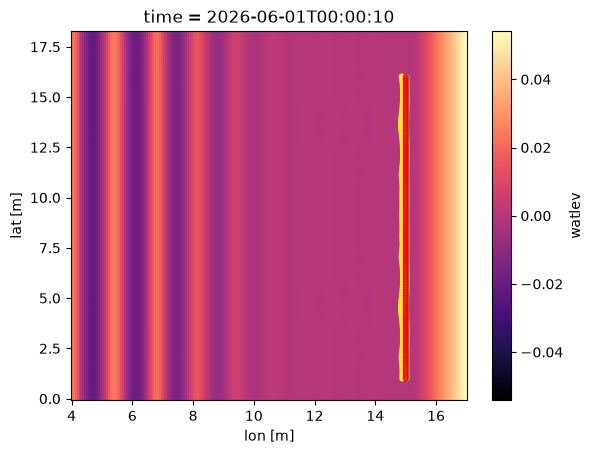

In [6]:
df = parcels.read_particlefile("output-quickstart.parquet")
waterlevel = ds.isel(time=2).watlev.plot(cmap="magma")
scatter = plt.scatter(df['x'], df['y'], c=df['t'], s=10)
plt.scatter(df['x'][:npart], df['y'][:npart], facecolors="none", edgecolors='r', s=10) # starting positions